In [1]:
!pip install tf-levenberg-marquardt 

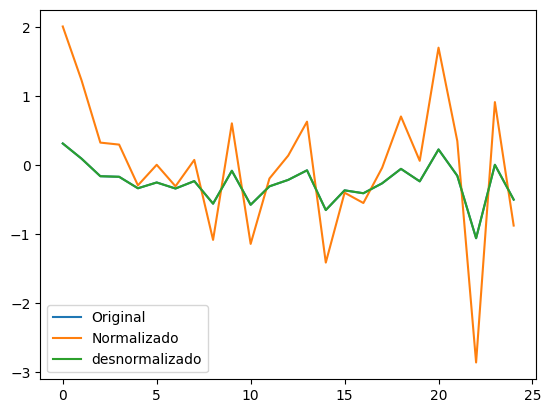

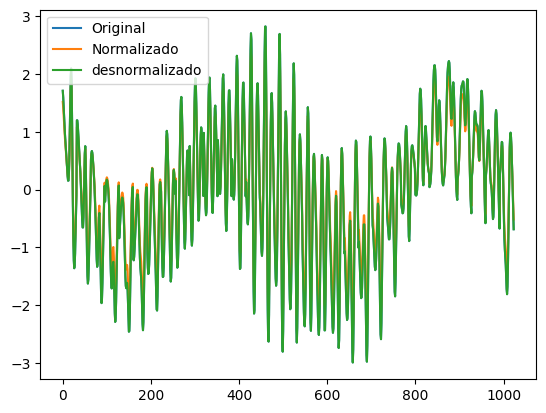

In [2]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

scaler = StandardScaler()
out_scaler = StandardScaler()

def peaks(grid):
    x = np.linspace(-2, 2, grid)
    y = np.linspace(-2, 2, grid)
    x, y = np.meshgrid(x, y)
    z = 3*(1-x)**2 * np.exp(-(x**2) - (y+1)**2) - 10*(x/5 - x**3 - y**5) * np.exp(-x**2 - y**2) - 1/3 * np.exp(-(x+1)**2 - y**2)
    return x, y, z

def create_dataframe_(filepaths, grid):
    x, y, z = peaks(grid)
    z_pred_total = np.zeros_like(z).ravel()
    for filepath in filepaths:
        z_pred = pd.read_excel(filepath, usecols=['Z_pred']).squeeze('columns').to_numpy()
        z_pred_total += z_pred
    z_residuo= z.flatten() - (z_pred_total)
    data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z_residuo}
    df = pd.DataFrame(data)
    return df
 
def create_dataframe(grid):
   x, y, z = peaks(grid)
   data = {'X': x.flatten(), 'Y': y.flatten(), 'Z': z.flatten()}
   df = pd.DataFrame(data)
   return df

def show_norm(df, label="Peaks", plot=False):
    df_norm = pd.DataFrame(scaler.fit_transform(df), columns=df.columns)
    df_denorm = pd.DataFrame(scaler.inverse_transform(df_norm), columns=df_norm.columns)

    if (plot):
        df.plot(title=f"{label}: Original data")
        df_norm.plot(title=f"{label}: Normalized data")
        df_denorm.plot(title=f"{label}: Denormalized data")
    return (df_norm)


def test_out_scaler(df):
    out = df["Z"].values.reshape(-1, 1)  
    plt.plot(out, label='Original')
    out_scaler.fit(out)
    norm = out_scaler.transform(out)
    plt.plot(norm, label='Normalizado')
    plt.plot(out_scaler.inverse_transform(norm), label='desnormalizado')
    plt.legend()
    plt.show()

arquivos_25 = [
    "25_model_13_2_14.xlsx",
    "25_model_12_6_0.xlsx",
    "25_model_33_7_2.xlsx"
]
arquivos_1000 = [
    "1000_model_13_2_14.xlsx",
    "1000_model_12_6_0.xlsx",
    "1000_model_33_7_2.xlsx"
]
df_25 = create_dataframe_(arquivos_25, grid=5)
df_25_norm = show_norm(df_25)
test_out_scaler(df_25)

df_1000 = create_dataframe_(arquivos_1000,grid=32)
df_1000_norm = show_norm(df_1000)
test_out_scaler(df_1000)



In [3]:
def split_df(df):
    _input = np.vstack([df['X'], df['Y']]).T
    _output = np.array(df['Z'])
    return (_input, _output)

In [4]:
import tensorflow as tf
import numpy as np
from keras import regularizers
from keras import initializers
import tf_levenberg_marquardt as lm

# layers, neurons
class ShuffleArchitecture:
    def __init__(self, input_size, hidden_sizes, output_size, act_h, act_o, param_reg):
        self.input_size = input_size
        self.hidden_sizes = hidden_sizes
        self.output_size = output_size
        self.act_h = act_h
        self.act_o = act_o
        self.regularizer = regularizers.L2(param_reg)
        self.initializer = initializers.RandomUniform(minval=-0.5, maxval=0.5, seed=np.random.randint(1, 10000))

    def compute_k(self):
        total_parameters = 0
        for layer in self.model.layers:
            weights = layer.get_weights()
            if len(weights) > 0:  
                for w in weights:
                    total_parameters += np.prod(w.shape)
        return total_parameters
        
    def set_architecture(self):
        self.model = tf.keras.Sequential()
        self.model.add(tf.keras.layers.Dense(self.hidden_sizes[0],
                        input_shape=(self.input_size,),
                        activation=self.act_h,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,                        
                        ))  # input layer

        for size in self.hidden_sizes[1:]:  # hidden layers
            self.model.add(tf.keras.layers.Dense(size,
                            activation=self.act_h,
                            kernel_regularizer=self.regularizer,
                            kernel_initializer=self.initializer,  
                        ))

        self.model.add(tf.keras.layers.Dense(self.output_size,
                        activation=self.act_o,
                        kernel_regularizer=self.regularizer,
                        kernel_initializer=self.initializer,  
                        ))  # output layer

    def create_model(self, _learning_rate):
        mse_loss = lm.loss.MeanSquaredError()

        self.model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=_learning_rate),
            loss=tf.keras.losses.MeanSquaredError(),
        )
        self.lm_model = lm.model.ModelWrapper(
            tf.keras.models.clone_model(self.model)
        )
        self.lm_model.compile(
            optimizer=tf.keras.optimizers.SGD(learning_rate=_learning_rate),
             loss=lm.loss.MeanSquaredError()
        )
        return self.lm_model


2025-11-05 20:39:09.747602: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 20:39:09.800625: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-11-05 20:39:09.800667: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-11-05 20:39:09.802185: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-05 20:39:09.811686: I external/local_tsl/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-05 20:39:09.813017: I tensorflow/core/platform/cpu_feature_guard.cc:1

In [5]:
from sklearn.model_selection import train_test_split
from keras.callbacks import EarlyStopping
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error 

class TrainWithSmallDataset:
    def __init__(self, batch_size=1000):
        self.batch_size = batch_size
        self.betters = []
        self.k = 0

    def create_dataset(self, input, output):
      input = tf.expand_dims(tf.cast(input, tf.float32), axis=-1)
      output = tf.expand_dims(tf.cast(output, tf.float32), axis=-1)
      dataset = tf.data.Dataset.from_tensor_slices((input, output))
      dataset = dataset.shuffle(len(input))
      dataset = dataset.batch(self.batch_size).cache()
      dataset = dataset.prefetch(tf.data.experimental.AUTOTUNE)
      return (dataset, input, output)

    def split_dataset(self, input, output, sup_input, sup_output):
      input_train, input_vt, output_train, output_vt = train_test_split(input, output, test_size=0.3, shuffle = True)
      input_val, input_test, output_val, output_test = train_test_split(input_vt, output_vt, test_size=0.5, shuffle = True)

      self.train_dataset, self.train_input, self.train_output = self.create_dataset(input_train, output_train)
      self.val_dataset, self.val_input, self.val_output = self.create_dataset(input_val, output_val)
      self.test_dataset, self.test_input, self.test_output = self.create_dataset(input_test, output_test)
      self.vt_dataset, self.vt_input, self.vt_output = self.create_dataset(input_vt, output_vt)
      self.sup_dataset, self.sup_input, self.sup_output = self.create_dataset(sup_input, sup_output)
      self.dataset, self.input, self.output = self.create_dataset(input, output)

      self._data = (input, output)
      self._train = (input_train, output_train)
      self._vt = (input_vt, output_vt)
      self._val = (input_val, output_val)
      self._test = (input_test, output_test)
      self._sup = (sup_input, sup_output)

    def train_using_lm(self, train_dataset, epochs=1000):
      early_stopping_monitor = EarlyStopping(monitor='val_loss',
                                              patience=6,
                                              restore_best_weights=True)

      self.results = self.lm_model.fit(train_dataset,
                                            epochs=epochs,
                                            validation_data=self.val_dataset,
                                            callbacks=[early_stopping_monitor],
                                            verbose=0)
      print ("Stopped at epoch: ", early_stopping_monitor.stopped_epoch)
    
    def get_new_metrics(self, orig, pred, r2, mse):
      n = len(orig) # N: quantidade de saidas
      k = self.k
      waste = (orig.flatten() - pred.flatten())

      mape = mean_absolute_percentage_error(orig, pred)  
      r2_adj = 1 - (((n - 1)/(n - k - 1)) * (1 - r2))
      rsd = np.sqrt(np.sum(waste ** 2) / (n - 2))
      rmse = root_mean_squared_error(orig, pred)          
      aic = (-2 * np.log(mse)) + (2 * k)
      bic = (-2 * np.log(mse)) + (k * np.log(n))
      return (mape, r2_adj, rsd, rmse, aic, bic)
      

    def get_metrics(self):
          # Calculando a saida com os dados normalizados
          pred = self.lm_model.predict(self.input).flatten()
          test_pred = self.lm_model.predict(self.test_input).flatten()
          val_pred = self.lm_model.predict(self.val_input).flatten()
          vt_pred = self.lm_model.predict(self.vt_input).flatten()
          sup_pred = self.lm_model.predict(self.sup_input).flatten()

          # Calculando as metricas com a saida desnormalizada
          pred_denorm = out_scaler.inverse_transform(pred.reshape(-1, 1))
          test_pred_denorm = out_scaler.inverse_transform(test_pred.reshape(-1, 1))
          val_pred_denorm = out_scaler.inverse_transform(val_pred.reshape(-1, 1))
          vt_pred_denorm = out_scaler.inverse_transform(vt_pred.reshape(-1, 1))
          sup_pred_denorm = out_scaler.inverse_transform(sup_pred.reshape(-1, 1))

          out_denorm = out_scaler.inverse_transform(self._data[1].reshape(-1, 1))
          test_denorm = out_scaler.inverse_transform(self._test[1].reshape(-1, 1))
          val_denorm = out_scaler.inverse_transform(self._val[1].reshape(-1, 1))
          vt_denorm = out_scaler.inverse_transform(self._vt[1].reshape(-1, 1))    
          sup_denorm = out_scaler.inverse_transform(self._sup[1].reshape(-1, 1))

          r2 = r2_score(out_denorm, pred_denorm)
          r2_test = r2_score(test_denorm, test_pred_denorm)
          r2_val = r2_score(val_denorm, val_pred_denorm)
          r2_vt = r2_score(vt_denorm,  vt_pred_denorm)
          r2_sup = r2_score(sup_denorm,  sup_pred_denorm)

          mse = mean_squared_error(out_denorm, pred_denorm)
          mse_test = mean_squared_error(test_denorm, test_pred_denorm)
          mse_val = mean_squared_error(val_denorm, val_pred_denorm)
          mse_vt = mean_squared_error(vt_denorm,  vt_pred_denorm)
          mse_sup = mean_squared_error(sup_denorm,  sup_pred_denorm)
          
          mape, r2_adj, rsd, rmse, aic, bic = self.get_new_metrics(out_denorm, pred_denorm, r2, mse)
          metrics = {
                          'r2': r2,
                          'r2_sup': r2_sup,
                          'r2_test': r2_test,
                          'r2_val': r2_val,
                          'r2_vt': r2_vt,
                          'mse': mse,
                          'mse_sup': mse_sup,
                          'mse_test': mse_test,
                          'mse_val': mse_val,
                          'mse_vt': mse_vt,
                          'mape': mape,
                          'rmse': rmse,
                          'r2_adj': r2_adj,
                          'rsd': rsd,
                          'aic': aic,
                          'bic': bic
                          }

          return metrics

In [6]:
import pickle
from itertools import product

class Tester:
  def __init__(self, run_times=500, dataset_run_times=10):
    self.run_times = run_times
    self.better_metrics = {}
    self.dataset_run_times = dataset_run_times
    self.input_25, self.output_25 = split_df(df_25_norm)
    self.input_1000, self.output_1000 = split_df(df_1000_norm)
  
  def setArchitecure(self, trainer, _hidden_sizes, _pg, _lr):
    shuffler = ShuffleArchitecture(input_size=2,
                                    hidden_sizes=_hidden_sizes,
                                    output_size=1,
                                    act_h='tanh',
                                    act_o='linear',
                                    param_reg=_pg)
    shuffler.set_architecture()    
    trainer.lm_model = shuffler.create_model(_lr)
    trainer.k = shuffler.compute_k()

  def Train(self, trainer, epochs=1000):
    trainer.train_using_lm(trainer.train_dataset, epochs=epochs)
    return(trainer.get_metrics(), trainer.lm_model)

  def SaveModelWeights(self, model, fileName):
    path = f"content/models/{fileName}.keras"
    open(path,'w').close()
    model.save_weights(path)

  def SaveDataset(self, trainer, fileName):
    path = f"content/dataset/{fileName}.pkl" 
    with open(path, 'wb') as f:
      pickle.dump((trainer._data, trainer._train, trainer._vt, trainer._val, trainer._test), f)
      
  def LoopWeights(self, sort_by, boundarie, trainer, idx):
    better_model = 0
    save = False

    for i in range(self.run_times):
      print (f"+++++++++++ [{idx}] | {i + 1} ++++++++++++++++++")
      metrics, model = self.Train(trainer)
      if (metrics[sort_by] >= boundarie): # should be >= to acsending metrics
        fileName = f"model_{idx}_{better_model}"
        self.SaveModelWeights(model, fileName)
        self.better_metrics[fileName] = metrics
        better_model += 1
        save = True
    return(save)
 
  def Loop(self, sort_by, boundarie, hidden_sizes, regularizers, learning_rate):
    trainer = TrainWithSmallDataset()

    for count, (hidden_size, reg, lr) in enumerate(product(hidden_sizes, regularizers, learning_rate), start=1):
      header =  f"Hidden Size={hidden_size}, regularizer={reg}, learning_rate={lr}"
      print(f"Testando combinacao{count}: {header}")
      self.setArchitecure(trainer, hidden_size, reg, lr)
      for j in range(self.dataset_run_times):
        trainer.split_dataset(self.input_25, self.output_25, self.input_1000, self.output_1000)
        if (self.LoopWeights(sort_by, boundarie, trainer, f"{count}_{j}") == True):
          self.SaveDataset(trainer, f"dataset_{count}_{j}")
          self.DisplayBetterResults('mse_sup', header, f"{count}_{j}")
        self.better_metrics = {}

  def DisplayBetterResults(self, sort_by, header, dataset=0):
    df = pd.DataFrame.from_dict(self.better_metrics, orient='index')
    df = df.sort_values([sort_by])
    display(df)
    path = f'content/results/metrics_{dataset}'
    df.to_excel(f"{path}.xlsx", index=True)
    print(f"DataFrame salvo em {path}")
    with open(f"{path}.txt", 'w') as arquivo:
      arquivo.write(header)

# Treinando com 25 dados


In [7]:
tester = Tester(run_times=25, dataset_run_times=10)
tester.Loop(sort_by='r2',
            boundarie = 0.7,
            hidden_sizes = [[3], [4], [5], [6], [7], [8], [9], [11]],
            regularizers=[0.2, 0.05],
            learning_rate=[0.01, 0.1]) 

Testando combinacao1: Hidden Size=[3], regularizer=0.2, learning_rate=0.01
+++++++++++ [1_0] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [1_0] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 7 ++++++++++++++++++
Stopped at epoch:  26
32/32 [==============================] - 0s 2ms/step
+++++++++++ [1_0] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_9_5_2,0.721047,-1.116023,-6.853810,0.336353,-0.191896,0.387626,2.940370,0.994315,0.635854,0.815085,15.984357,0.622596,-1.231623,0.649101,43.895431,69.491823
model_9_5_1,0.759628,-1.125510,-3.448257,0.604612,0.311264,0.334015,2.953553,0.563162,0.378829,0.470996,6.122319,0.577941,-0.922980,0.602545,44.193137,69.789529
model_9_5_0,0.703470,-1.266841,-5.614671,0.770986,0.227278,0.412051,3.149943,0.837437,0.219423,0.528430,13.678153,0.641912,-1.372242,0.669239,43.773218,69.369610


DataFrame salvo em content/results/metrics_9_5
+++++++++++ [9_6] | 1 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 2 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 4 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 5 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 6 ++++++++++++++++++
Stopped at epoch:  8
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 7 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 8 ++++++++++++++++++
Stopped at epoch:  14
32/32 [==============================] - 0s 2ms/step
+++++++++++ [9_6] | 9 ++++++++++

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_14_5_0,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277516,0.541727,6.068636,0.56479,52.45197,82.923866
model_14_5_22,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_21,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_20,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_19,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_18,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_17,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_16,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_15,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865
model_14_5_14,0.788807,-1.803502,-2.32897,-1.274012,-1.26625,0.293469,3.895673,0.882856,0.951323,0.917089,40.277515,0.541727,6.068636,0.56479,52.45197,82.923865


DataFrame salvo em content/results/metrics_14_5
+++++++++++ [14_6] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 2 ++++++++++++++++++
Stopped at epoch:  7
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [14_6] | 9 +

...

DataFrame salvo em content/results/metrics_32_7
+++++++++++ [32_8] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_8] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_8] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 4ms/step
+++++++++++ [32_8] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_8] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_8] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_8] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_8_21,0.748516,-2.076127,-0.045650,0.581434,0.622174,0.349456,4.274505,1.423907,0.736136,1.080022,0.829312,0.591148,1.287410,0.616314,92.102757,146.952169
model_32_8_20,0.751011,-2.077260,-0.034094,0.588004,0.626948,0.345989,4.276080,1.408170,0.724581,1.066376,0.874086,0.588208,1.284559,0.613249,92.122699,146.972111
model_32_8_19,0.753687,-2.078541,-0.021273,0.595232,0.632226,0.342270,4.277861,1.390711,0.711868,1.051289,0.923347,0.585039,1.281501,0.609945,92.144308,146.993720
model_32_8_18,0.756541,-2.079994,-0.007051,0.603178,0.638057,0.338304,4.279879,1.371346,0.697894,1.034619,0.977631,0.581639,1.278239,0.606401,92.167619,147.017032
model_32_8_17,0.759565,-2.081645,0.008714,0.611900,0.644496,0.334102,4.282173,1.349877,0.682554,1.016215,1.037351,0.578016,1.274783,0.602623,92.192618,147.042030
model_32_8_16,0.762744,-2.083526,0.026176,0.621467,0.651598,0.329685,4.284787,1.326099,0.665729,0.995914,1.102971,0.574182,1.271150,0.598626,92.219233,147.068645
model_32_8_15,0.766050,-2.085676,0.045500,0.631943,0.659423,0.325091,4.287775,1.299785,0.647304,0.973545,1.174937,0.570168,1.267372,0.594441,92.247297,147.096709
model_32_8_14,0.769443,-2.088145,0.066857,0.643399,0.668034,0.320375,4.291205,1.270702,0.627157,0.948930,1.253940,0.566017,1.263493,0.590114,92.276523,147.125935
model_32_8_13,0.772867,-2.090990,0.090423,0.655905,0.677495,0.315618,4.295159,1.238610,0.605162,0.921887,1.340386,0.561799,1.259580,0.585716,92.306447,147.155859
model_32_8_12,0.776240,-2.094288,0.116376,0.669529,0.687868,0.310931,4.299741,1.203269,0.581202,0.892235,1.434861,0.557612,1.255726,0.581350,92.336369,147.185782


DataFrame salvo em content/results/metrics_32_8
+++++++++++ [32_9] | 1 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 2 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 3 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 4 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 5ms/step
+++++++++++ [32_9] | 5 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 6 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 7 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 3ms/step
+++++++++++ [32_9] | 8 ++++++++++++++++++
Stopped at epoch:  6
32/32 [==============================] - 0s 2ms/step
+++++++++++ [32_9] | 9 +

,r2,r2_sup,r2_test,r2_val,r2_vt,mse,mse_sup,mse_test,mse_val,mse_vt,mape,rmse,r2_adj,rsd,aic,bic
model_32_9_24,0.748076,-1.390268,-3.197727,-1.851591,-2.616812,0.350067,3.321453,1.443201,0.735503,1.089352,0.756702,0.591665,1.287913,0.616853,92.099261,146.948673
model_32_9_23,0.750203,-1.393016,-3.149813,-1.835462,-2.582561,0.347112,3.325272,1.426728,0.731343,1.079036,0.738263,0.589162,1.285483,0.614244,92.116217,146.965629
model_32_9_22,0.752525,-1.396127,-3.097045,-1.817273,-2.544654,0.343885,3.329595,1.408586,0.726652,1.067619,0.717523,0.586417,1.282829,0.611382,92.134896,146.984308
model_32_9_21,0.755054,-1.399655,-3.039000,-1.796709,-2.502720,0.340370,3.334497,1.388630,0.721348,1.054989,0.695580,0.583413,1.279938,0.608250,92.155443,147.004855
model_32_9_20,0.757804,-1.403664,-2.975231,-1.773356,-2.456327,0.336549,3.340068,1.366706,0.715324,1.041015,0.724127,0.580128,1.276795,0.604826,92.178023,147.027435
model_32_9_19,0.760787,-1.408228,-2.905270,-1.746737,-2.404998,0.332404,3.346410,1.342653,0.708459,1.025556,0.756265,0.576545,1.273387,0.601090,92.202806,147.052218
model_32_9_18,0.764013,-1.413437,-2.828648,-1.716238,-2.348209,0.327922,3.353649,1.316310,0.700592,1.008451,0.792442,0.572644,1.269700,0.597023,92.229961,147.079373
model_32_9_17,0.767491,-1.419398,-2.744906,-1.681103,-2.285369,0.323088,3.361932,1.287519,0.691530,0.989525,0.833065,0.568408,1.265724,0.592607,92.259661,147.109073
model_32_9_16,0.771230,-1.426236,-2.653585,-1.640358,-2.215801,0.317892,3.371434,1.256122,0.681020,0.968571,0.878564,0.563819,1.261451,0.587822,92.292086,147.141498
model_32_9_15,0.775234,-1.434104,-2.554282,-1.592779,-2.138753,0.312329,3.382367,1.221982,0.668749,0.945365,0.929416,0.558864,1.256875,0.582656,92.327398,147.176810


DataFrame salvo em content/results/metrics_32_9
